# Vtora laboratoriska vezba


In [147]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
import pandas as pd
from scipy import stats 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import BayesianRidge


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # За евалуација на модели
data = pd.read_csv('Student_Performance.csv')
rows = data.values
features = []
y = np.array( [i[-1] for i in rows])

#Yes ke stane 1, No ke stane 0 so cel da bidat numericski
for i in rows:
    li = []
    for j in i[:-1]:
        if j == 'Yes':
            li.append(1)
        elif j == 'No':
            li.append(0)
        else:
            li.append(j)
   

    features.append(li)
X =np.array(features) 
print('Targets: ',y)
print('Features:\n', X)

data.head(10)
feature_names = ['Extracurricular Activities', 'Hours Studied',
                  'Previous Scores', 'Sample Question Papers Practiced',
                 'Sleep Hours']




Targets:  [91. 65. 45. ... 74. 95. 64.]
Features:
 [[ 7 99  1  9  1]
 [ 4 82  0  4  2]
 [ 8 51  1  7  2]
 ...
 [ 6 83  1  8  5]
 [ 9 97  1  7  0]
 [ 7 74  0  8  1]]


In [118]:
number_of_features = 5
instances = data.shape[0]
print('Broj na instanci', instances)
print('Number of features:', number_of_features)


Broj na instanci 10000
Number of features: 5


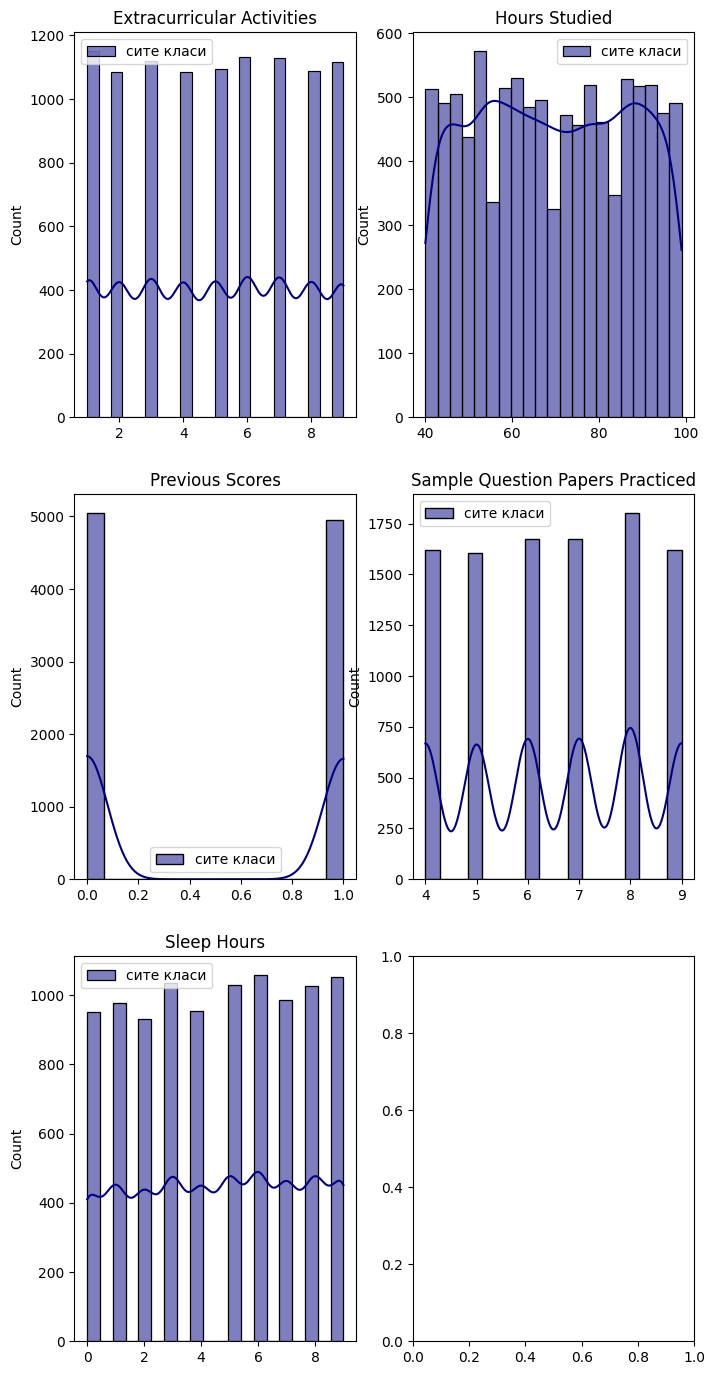

In [128]:

fig = plt.figure(figsize=(8, 17))
fig.subplots(nrows=3, ncols=2)
for feat_i in range(number_of_features): #хистограми за секој атрибут
    ax = plt.subplot(3,2, feat_i+1)
    plt.title(feature_names[feat_i])
    sns.histplot(X[:,feat_i],color='navy',label='сите класи',kde=True,stat="count") # се прикажува хистограм на вредностите на соодветниот атрибут без разлика во која класа припаѓаат
    plt.legend()
plt.show()

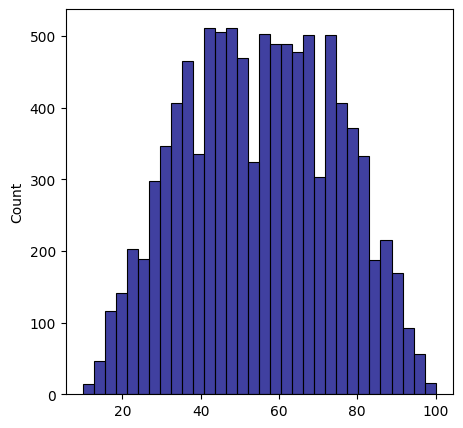

In [129]:
fig = plt.figure(figsize=(5, 5))
sns.histplot(y, color = "navy")
plt.show()

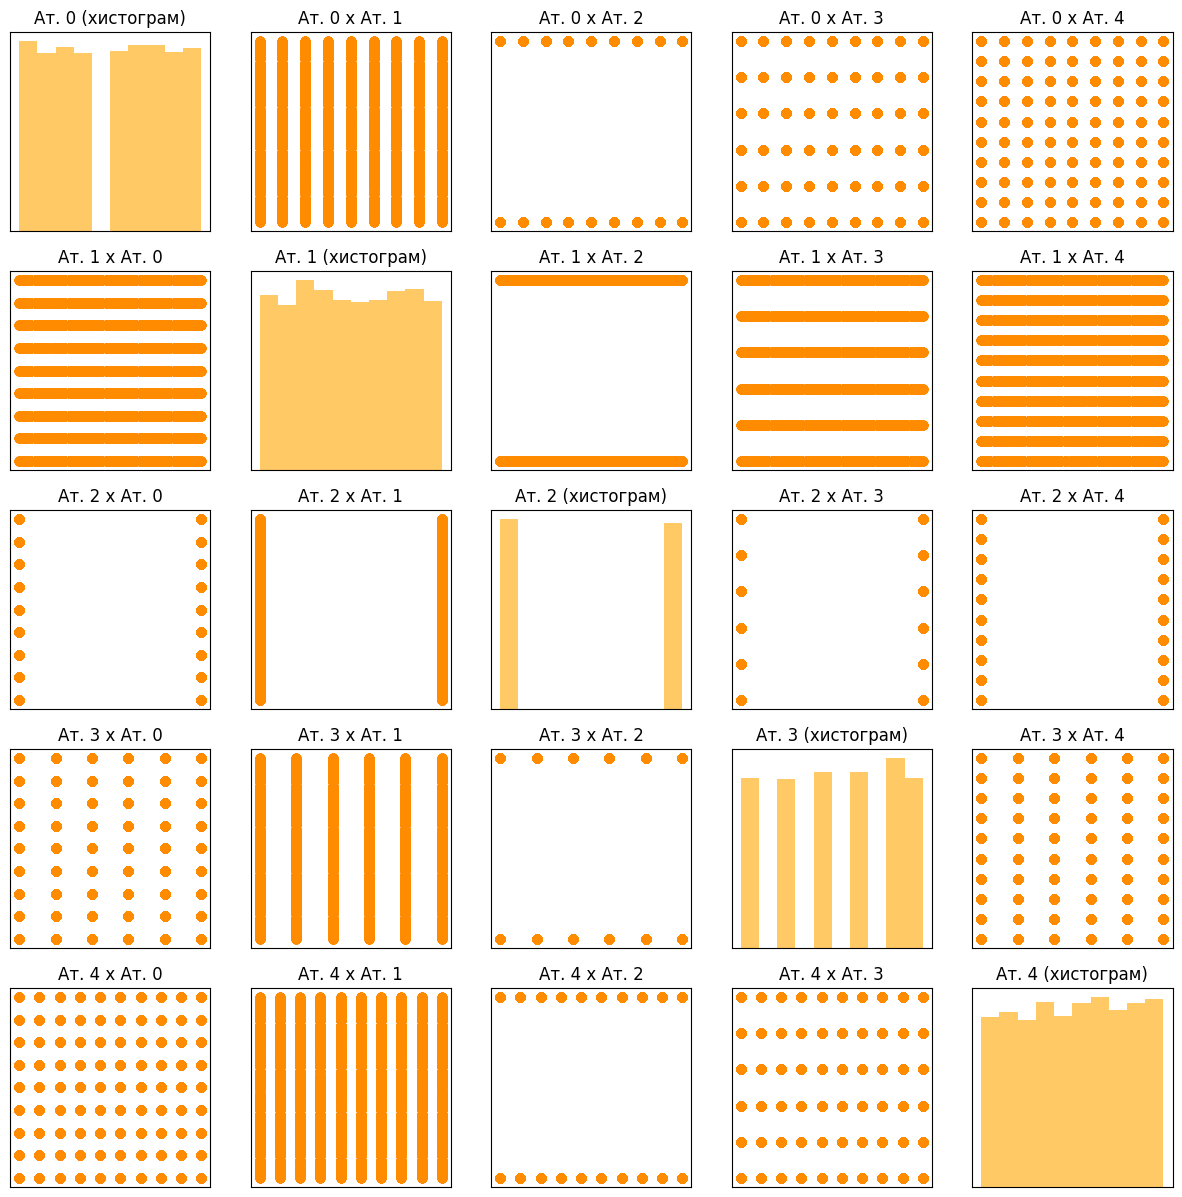

In [130]:
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
          plt.hist(X[:, feature_i], alpha=.6, color="orange")
          plt.title("Ат. "+str(feature_i)+" (хистограм)")
        else:
          plt.scatter(X[:,feature_i], X[:,feature_j], color="darkorange")
          plt.title("Ат. "+str(feature_i)+" x Ат. "+str(feature_j)) # Атрибут i x Атрибут ј
          #plt.title(feature_names[feature_i] +" x "+feature_names[feature_j]) # Атрибут i x Атрибут ј
        plt.xticks(())
        plt.yticks(())
plt.show()

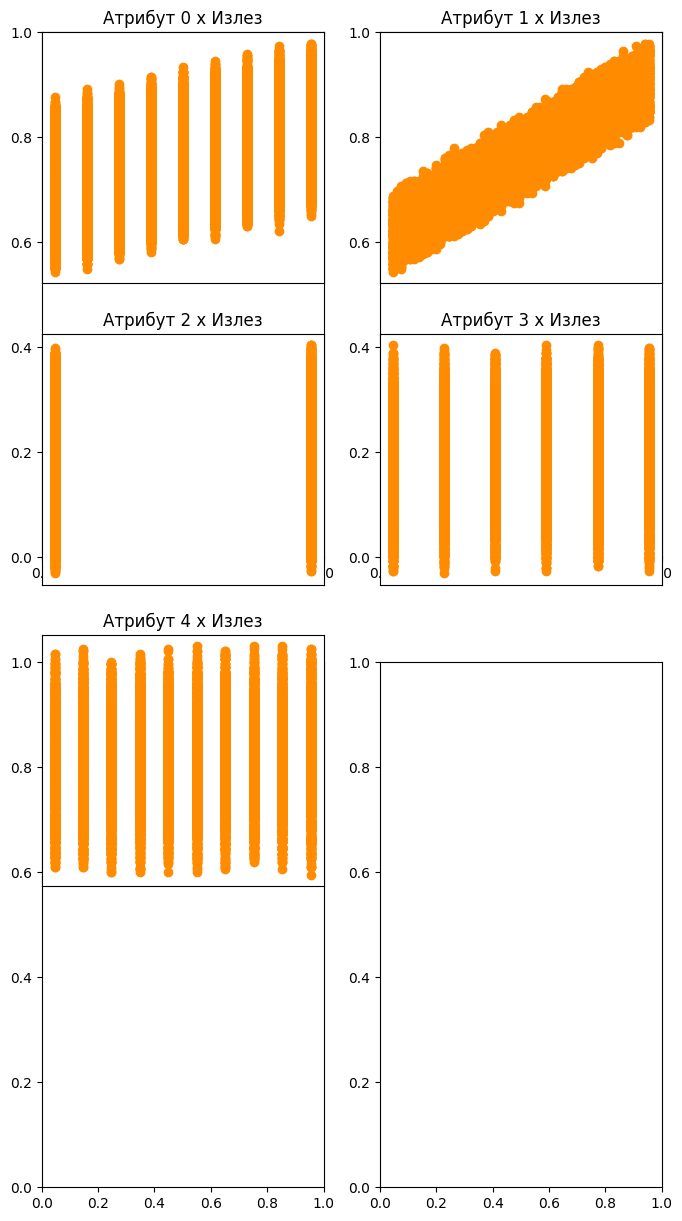

In [131]:
fig = plt.figure(figsize=(8, 15))
fig.subplots(nrows=(int)(number_of_features/2),ncols=2)
for feat_i in range(number_of_features):
    ax = plt.subplot(4,2, feat_i+1)
    plt.scatter( X[:,feat_i], y, color="darkorange")
    plt.xticks(())
    plt.yticks(())
    plt.title("Атрибут "+str(feat_i)+" x Излез")
plt.show()

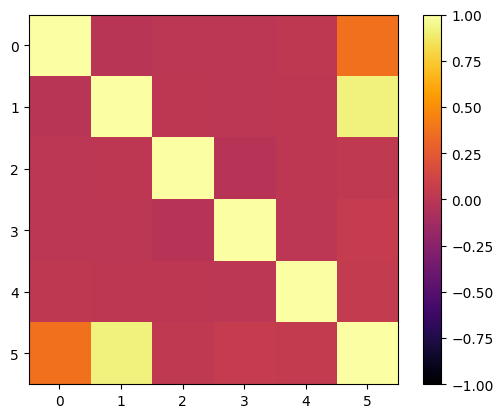

In [132]:
correlation_matrix = np.zeros((number_of_features+1,number_of_features+1))
# прво ги пресметуваме присоновите корелациски коефициенти за сите парови атрибути
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        corr, _ = stats.pearsonr(X[:,feature_i], X[:,feature_j])
        correlation_matrix[feature_i][feature_j] = corr
# потоа ги пресметуваме пирсоновите корелациски коефициенти за секој атрибут со целната променлива
for feature_i in range(number_of_features):
    target_i = number_of_features
    corr, _ = stats.pearsonr(X[:,feature_i], y)
    correlation_matrix[feature_i][target_i] = corr
    correlation_matrix[target_i][feature_i] = corr
# на крај го пресметуваме пирсоновиот корелациски коефициент за целната променлива само со себе (ова може и да се изостави зашто резултатот е 1)
corr, _ = stats.pearsonr(y, y)
correlation_matrix[target_i][target_i] = corr
corr, _ = stats.pearsonr(X[:,feature_i], y)

plt.figure()
plt.imshow(correlation_matrix, cmap = "inferno", vmin=-1, vmax=1) # ја исцртуваме матрицата со imshow
plt.colorbar()
plt.show()

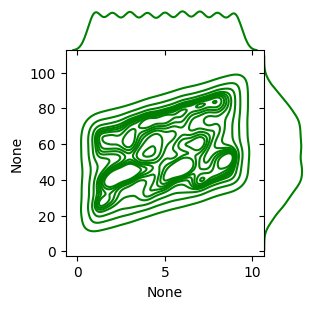

In [133]:
sns.jointplot(x=X[:,0], y=y, kind="kde", space=0, color="g", height = 3)
plt.show()
# откоментирајте го следниот код за приказ за секој атрибут
#for feature_i in range(number_of_features):
#    sns.jointplot(x=X[:,feature_i], y=y, kind="kde", space=0, color="g", height = 3)
#plt.show()

# Regularizacija

In [173]:
scaler = MinMaxScaler()
tempX = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(tempX, y, test_size=0.30, random_state=42)


# Linearna regresija

Коефициенти W:  [22.87161784 59.91566786  0.58171285  2.3983838   1.71354741]
Пресек W0:  11.561907234173418
Средна квадратна грешка: 4.066563824092734
Средна апсолутна грешка: 1.609043756404535
Корен на средна квадратна грешка: 2.0165722957763585
R-квадрат:  0.9890110607021135


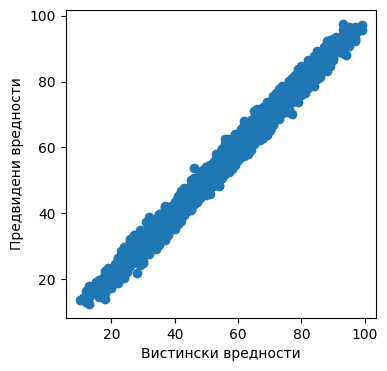

In [174]:
reg = LinearRegression().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

# Ridge

Коефициенти W:  [2.85834933 1.01551505 0.57839647 0.47943019 0.19036128]
Пресек W0:  -33.82981774643991
Средна квадратна грешка: 4.066616925082166
Средна апсолутна грешка: 1.6090258445352077
Корен на средна квадратна грешка: 2.0165854618840644
R-квадрат:  0.9890109172090873


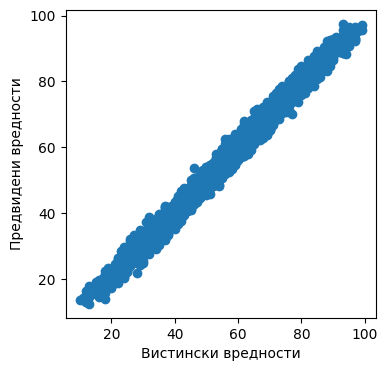

In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

reg = RidgeCV().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

# Lasso


Коефициенти W:  [2.81509486 1.01468394 0.         0.37152886 0.15282271]
Пресек W0:  -32.39347736668787
Средна квадратна грешка: 4.244016209979771
Средна апсолутна грешка: 1.636534517078814
Корен на средна квадратна грешка: 2.06010101936283
R-квадрат:  0.9885315370597635


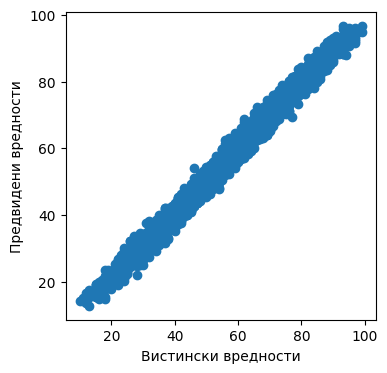

In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
#klasifikatorot sam pravi selekcija na karakteristiki i regularizacija
reg = LassoCV().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

# ElasticNetCV

Коефициенти W:  [2.69368183 1.01351032 0.         0.33768211 0.14857004]
Пресек W0:  -31.465527414867474
Средна квадратна грешка: 4.415493854596084
Средна апсолутна грешка: 1.6626815795859637
Корен на средна квадратна грешка: 2.1013076534853443
R-квадрат:  0.9880681587607512


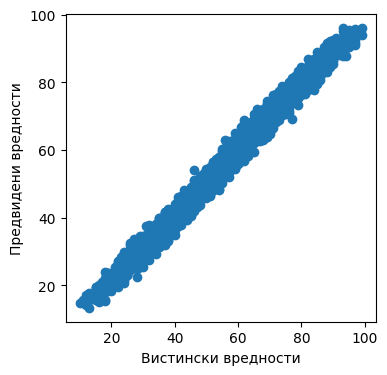

In [182]:
from sklearn.linear_model import ElasticNetCV
reg = ElasticNetCV().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

# ElasticNet


In [ ]:
from sklearn.linear_model import ElasticNet
reg = ElasticNet(alpha = 0.1, l1_ratio = 0.3).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (4250817734.py, line 14)